In [79]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from importlib import reload

In [80]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

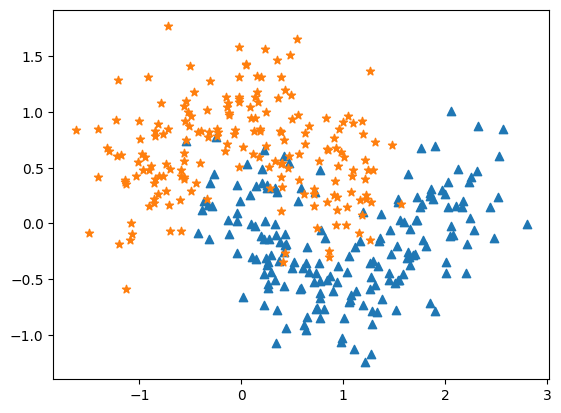

In [81]:
pos_class = y_train.astype(bool)
plt.scatter(X_train[pos_class, 0], X_train[pos_class, 1], marker='^')
neg_class = ~pos_class
plt.scatter(X_train[neg_class, 0], X_train[neg_class, 1], marker='*')
plt.show()

In [82]:
voting_clf = VotingClassifier(
estimators=[
    ('lr', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svc', SVC(random_state=42))
]
)
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [83]:
import ensambles
reload(ensambles)
from ensambles import VotingClassifier

custom_voting_clf = VotingClassifier(
estimators=[
    ('lr', LogisticRegression(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('svc', SVC(random_state=42))
]
)
custom_voting_clf.fit(X_train, y_train)

In [84]:
print('____ Custom ____')
for name, clf in custom_voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

print('____ Original ____')
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

____ Custom ____
lr = 0.864
rf = 0.896
svc = 0.896
____ Original ____
lr = 0.864
rf = 0.896
svc = 0.896


In [85]:
print('____ Custom ____')
print(custom_voting_clf.predict(X_test[:1]))

print('____ Original ____')
print(voting_clf.predict(X_test[:1]))

____ Custom ____
[1]
____ Original ____
[1]


In [86]:
print('____ Custom ____')
print([clf.predict(X_test[:1]) for clf in custom_voting_clf.estimators_])
print(custom_voting_clf.score(X_test, y_test))

print('____ Original ____')
print([clf.predict(X_test[:1]) for clf in voting_clf.estimators_])
print(voting_clf.score(X_test, y_test))

____ Custom ____
[array([1]), array([1]), array([0])]
0.912
____ Original ____
[array([1]), array([1]), array([0])]
0.912


In [87]:
print('____ Custom ____')
custom_voting_clf.voting = "soft"
custom_voting_clf.named_estimators["svc"].probability = True
custom_voting_clf.fit(X_train, y_train)
print(custom_voting_clf.score(X_test, y_test))

print('____ Original ____')
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
print(voting_clf.score(X_test, y_test))

____ Custom ____
0.92
____ Original ____
0.92


------------- **TEST BaggingClassifier** -------------

In [142]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [117]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                                max_samples=100, n_jobs=-1, random_state=42, oob_score=True)

bag_clf.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,500
,max_samples,100
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,True
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [118]:
import ensambles
reload(ensambles)
from ensambles import BaggingClassifier

custom_bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500,
                                max_samples=100, random_state=42, oob_score=True)

custom_bag_clf.voting = 'soft'

custom_bag_clf.fit(X_train, y_train)

In [119]:
print('____ Custom ____')
print(custom_bag_clf.score(X_test, y_test))
print(custom_bag_clf.oob_score_)

print('____ Original ____')
print(bag_clf.score(X_test, y_test))
print(bag_clf.oob_score_)

____ Custom ____
0.912
0.9226666666666666
____ Original ____
0.904
0.9253333333333333


------------- **TEST RandomForestClasifier** -------------

In [224]:
print('____ Custom ____')
reload(ensambles)
from ensambles import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                random_state=42, oob_score=True)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
print('OOB:', rnd_clf.oob_score_)
print('ACC:', accuracy_score(y_test, rnd_clf.predict(X_test)))
print('feature_imp:', rnd_clf.feature_importances_)

print('____ Original ____')
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16,
                                    n_jobs=-1, random_state=42, oob_score=True)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
print('OOB:', rnd_clf.oob_score_)
print('ACC:', accuracy_score(y_test, rnd_clf.predict(X_test)))
print('feature_imp:', rnd_clf.feature_importances_)

____ Custom ____
OOB: 0.9146666666666666
ACC: 0.92
feature_imp: [0.41875066 0.58124934]
____ Original ____
OOB: 0.9173333333333333
ACC: 0.912
feature_imp: [0.42253629 0.57746371]


**RandomForestRegressor**

In [217]:
np.random.seed(42)
X_quad = np.random.rand(500, 1) - 0.5 # a single random input feature
y_quad = (X_quad ** 2 + 0.025 * np.random.randn(500, 1)).ravel()

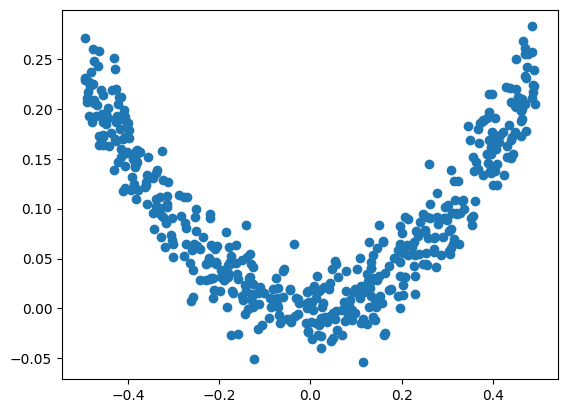

In [218]:
plt.scatter(X_quad, y_quad)

In [223]:
print('____ Custom ____')
reload(ensambles)
from ensambles import RandomForestRegressor
rnd_clf = RandomForestRegressor(n_estimators=500, random_state=42, oob_score=True)
rnd_clf.fit(X_quad, y_quad)
y_pred_rf = rnd_clf.predict(X_quad)
print('OOB:', rnd_clf.oob_score_)
print('RMSE:', root_mean_squared_error(y_quad, rnd_clf.predict(X_quad)))
print('feature_imp:', rnd_clf.feature_importances_)


print('____ Original ____')
from sklearn.ensemble import RandomForestRegressor
rnd_clf = RandomForestRegressor(n_estimators=500, n_jobs=-1, random_state=42, oob_score=True)
rnd_clf.fit(X_quad, y_quad)
y_pred_rf = rnd_clf.predict(X_quad)
print('OOB:', rnd_clf.oob_score_)
print('RMSE:', root_mean_squared_error(y_quad, rnd_clf.predict(X_quad)))
print('feature_imp:', rnd_clf.feature_importances_)

____ Custom ____
OOB: 0.8573904887447901
RMSE: 0.010996278124021895
feature_imp: [1.]
____ Original ____
OOB: 0.8576978172159626
RMSE: 0.010955981843686808
feature_imp: [1.]


**ExtraTreesClassifier**

In [220]:
print('____ Custom ____')
reload(ensambles)
from ensambles import ExtraTreesClassifier
rnd_clf = ExtraTreesClassifier(n_estimators=500, max_leaf_nodes=16,
                                random_state=42, oob_score=True)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
print('OOB:', rnd_clf.oob_score_)
print('ACC:', accuracy_score(y_test, rnd_clf.predict(X_test)))
print(rnd_clf.estimators_[0].splitter)

print('____ Original ____')
from sklearn.ensemble import ExtraTreesClassifier
rnd_clf = ExtraTreesClassifier(n_estimators=500, max_leaf_nodes=16,
                                    n_jobs=-1, random_state=42, oob_score=True, bootstrap=True)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)
print('OOB:', rnd_clf.oob_score_)
print('ACC:', accuracy_score(y_test, rnd_clf.predict(X_test)))

____ Custom ____
OOB: 0.8906666666666667
ACC: 0.912
random
____ Original ____
OOB: 0.8986666666666666
ACC: 0.912


**ExtraTreesRegressor**

In [221]:
print('____ Custom ____')
reload(ensambles)
from ensambles import ExtraTreesRegressor
rnd_clf = ExtraTreesRegressor(n_estimators=500, random_state=42, oob_score=True)
rnd_clf.fit(X_quad, y_quad)
y_pred_rf = rnd_clf.predict(X_quad)
print('OOB:', rnd_clf.oob_score_)
print('RMSE:', root_mean_squared_error(y_quad, rnd_clf.predict(X_quad)))
print(rnd_clf.estimators_[0].splitter)

print('____ Original ____')
from sklearn.ensemble import ExtraTreesRegressor
rnd_clf = ExtraTreesRegressor(n_estimators=500, n_jobs=-1, random_state=42, oob_score=True, bootstrap=True)
rnd_clf.fit(X_quad, y_quad)
y_pred_rf = rnd_clf.predict(X_quad)
print('OOB:', rnd_clf.oob_score_)
print('RMSE:', root_mean_squared_error(y_quad, rnd_clf.predict(X_quad)))

____ Custom ____
OOB: 0.8682212938586623
RMSE: 0.010564526197856031
random
____ Original ____
OOB: 0.868295953631476
RMSE: 0.01053797816251963


**Decision Tree**

In [156]:
from sklearn.datasets import load_iris
from sklearn.base import check_is_fitted, check_array
from graphviz import Source
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [157]:
iris = load_iris(as_frame=True)

X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

**splitter = random**

In [214]:
print('----- Custom -----')
from importlib import reload
import custom_decision_tree_clf
reload(custom_decision_tree_clf)

from custom_decision_tree_clf import DecisionTreeClassifier
custom_tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42, splitter='random')
custom_tree_clf.fit(X_iris, y_iris)
print('left ch:', custom_tree_clf.tree_.children_left)
print('right ch:', custom_tree_clf.tree_.children_right)
print('features:', custom_tree_clf.tree_.feature)
print('thresholds:', custom_tree_clf.tree_.threshold)
print('impurity:', custom_tree_clf.tree_.impurity)
print('values:')
print(custom_tree_clf.tree_.value)
print('ACC:', accuracy_score(y_iris, custom_tree_clf.predict(X_iris)))

export_graphviz(
    custom_tree_clf,
    out_file="custom_tree_depth3_rnd.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

print('----- Org -----')
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42, splitter='random')
tree_clf.fit(X_iris, y_iris)
print('left ch:', tree_clf.tree_.children_left)
print('right ch:', tree_clf.tree_.children_right)
print('features:', tree_clf.tree_.feature)
print('thresholds:', tree_clf.tree_.threshold)
print('impurity:', tree_clf.tree_.impurity)
print('values:')
print(tree_clf.tree_.value)
print('ACC:', accuracy_score(y_iris, tree_clf.predict(X_iris)))

export_graphviz(
    tree_clf,
    out_file="org_tree_depth3_rnd.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)


----- Custom -----
left ch: [1, -1, 3, -1, -1]
right ch: [2, -1, 4, -1, -1]
features: [np.int64(0), -2, np.int64(0), -2, -2]
thresholds: [np.float64(2.0822652602103666), -2, np.float64(5.334768088368443), -2, -2]
impurity: [np.float64(0.6666666666666665), np.float64(0.0), np.float64(0.5), np.float64(0.40816326530612246), np.float64(0.0)]
values:
[array([[0.33333333, 0.33333333, 0.33333333]]), array([[1., 0., 0.]]), array([[0. , 0.5, 0.5]]), array([[0.        , 0.71428571, 0.28571429]]), array([[0., 0., 1.]])]
ACC: 0.8666666666666667
----- Org -----
left ch: [ 1 -1  3  4 -1 -1 -1]
right ch: [ 2 -1  6  5 -1 -1 -1]
features: [ 1 -2  0  1 -2 -2 -2]
thresholds: [ 0.57149852 -2.          5.57477882  1.90954018 -2.         -2.
 -2.        ]
impurity: [0.66666667 0.         0.50975395 0.45879501 0.3616568  0.
 0.        ]
values:
[[[0.33333333 0.33333333 0.33333333]]

 [[1.         0.         0.        ]]

 [[0.00990099 0.4950495  0.4950495 ]]

 [[0.01315789 0.65789474 0.32894737]]

 [[0.01538

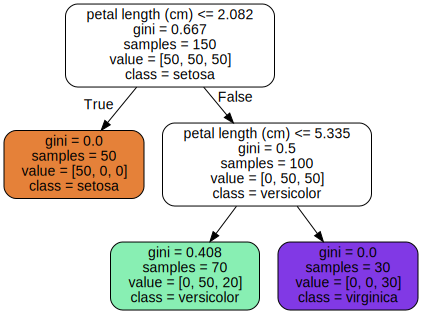

In [215]:
Source.from_file("custom_tree_depth3_rnd.dot")

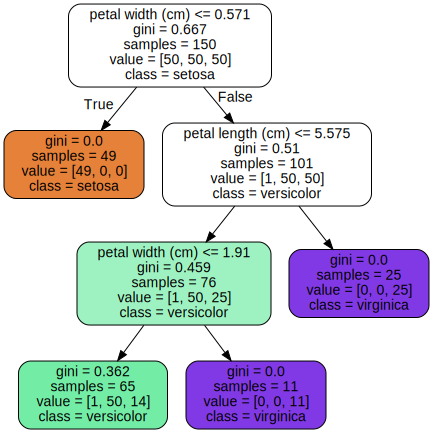

In [216]:
Source.from_file("org_tree_depth3_rnd.dot")

**splitter = best**

In [208]:
print('----- Custom -----')
from importlib import reload
import custom_decision_tree_clf
reload(custom_decision_tree_clf)

from custom_decision_tree_clf import DecisionTreeClassifier
custom_tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
custom_tree_clf.fit(X_iris, y_iris)
print('left ch:', custom_tree_clf.tree_.children_left)
print('right ch:', custom_tree_clf.tree_.children_right)
print('features:', custom_tree_clf.tree_.feature)
print('thresholds:', custom_tree_clf.tree_.threshold)
print('impurity:', custom_tree_clf.tree_.impurity)
print('values:')
print(custom_tree_clf.tree_.value)
print('ACC:', accuracy_score(y_iris, custom_tree_clf.predict(X_iris)))

export_graphviz(
    custom_tree_clf,
    out_file="custom_tree_depth3.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

print('----- Org -----')
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_iris, y_iris)
print('left ch:', tree_clf.tree_.children_left)
print('right ch:', tree_clf.tree_.children_right)
print('features:', tree_clf.tree_.feature)
print('thresholds:', tree_clf.tree_.threshold)
print('impurity:', tree_clf.tree_.impurity)
print('values:')
print(tree_clf.tree_.value)
print('ACC:', accuracy_score(y_iris, tree_clf.predict(X_iris)))

export_graphviz(
    tree_clf,
    out_file="org_tree_depth3.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)


----- Custom -----
left ch: [1, -1, 3, 4, -1, -1, 7, -1, -1]
right ch: [2, -1, 6, 5, -1, -1, 8, -1, -1]
features: [np.int64(1), -2, np.int64(1), np.int64(0), -2, -2, np.int64(0), -2, -2]
thresholds: [np.float64(0.6), -2, np.float64(1.7), np.float64(4.9), -2, -2, np.float64(4.8), -2, -2]
impurity: [np.float64(0.6666666666666665), np.float64(0.0), np.float64(0.5), np.float64(0.1680384087791495), np.float64(0.040798611111111174), np.float64(0.4444444444444444), np.float64(0.04253308128544431), np.float64(0.4444444444444444), np.float64(0.0)]
values:
[array([[0.33333333, 0.33333333, 0.33333333]]), array([[1., 0., 0.]]), array([[0. , 0.5, 0.5]]), array([[0.        , 0.90740741, 0.09259259]]), array([[0.        , 0.97916667, 0.02083333]]), array([[0.        , 0.33333333, 0.66666667]]), array([[0.        , 0.02173913, 0.97826087]]), array([[0.        , 0.33333333, 0.66666667]]), array([[0., 0., 1.]])]
ACC: 0.9733333333333334
----- Org -----
left ch: [ 1 -1  3  4 -1 -1  7 -1 -1]
right ch: [ 2 

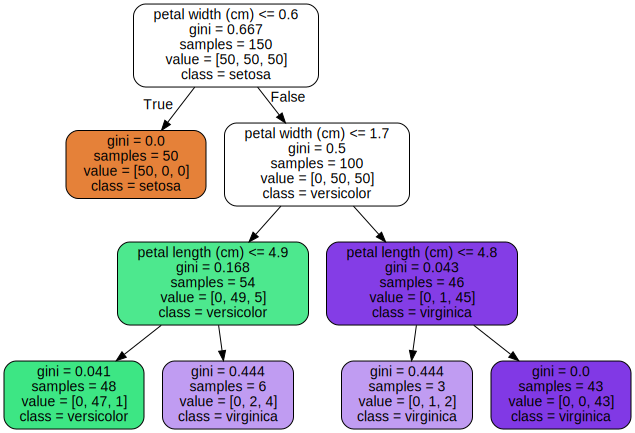

In [209]:
Source.from_file("custom_tree_depth3.dot")

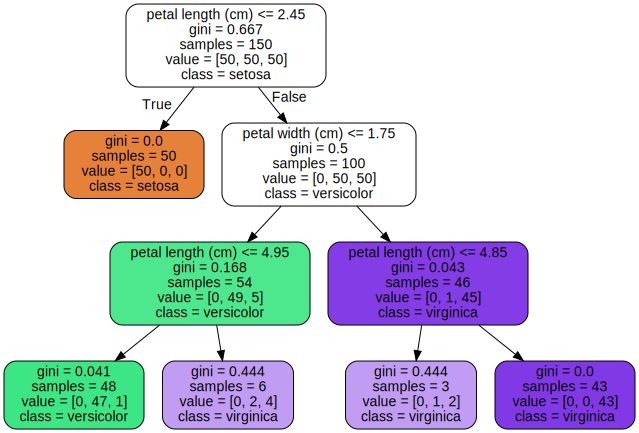

In [210]:
Source.from_file("org_tree_depth3.dot")

**Decision Tree Regressor**

In [212]:
print('----- Custom -----')
from importlib import reload
import custom_decision_tree_clf
reload(custom_decision_tree_clf)

from custom_decision_tree_clf import DecisionTreeRegressor
custom_tree_clf = DecisionTreeRegressor(max_depth=3, random_state=42)
custom_tree_clf.fit(X_quad, y_quad)
print('left ch:', custom_tree_clf.tree_.children_left)
print('right ch:', custom_tree_clf.tree_.children_right)
print('features:', custom_tree_clf.tree_.feature)
print('thresholds:', custom_tree_clf.tree_.threshold)
print('impurity:', custom_tree_clf.tree_.impurity)
print('values:')
print(custom_tree_clf.tree_.value[:3])
print('RMSE:', root_mean_squared_error(y_quad, custom_tree_clf.predict(X_quad)))

export_graphviz(
    custom_tree_clf,
    out_file="custom_tree_reg_depth3.dot",
    feature_names=["X_1"],
    rounded=True,
    filled=True
)

print('----- Org -----')
from sklearn.tree import DecisionTreeRegressor
tree_clf = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_clf.fit(X_quad, y_quad)
print('left ch:', tree_clf.tree_.children_left)
print('right ch:', tree_clf.tree_.children_right)
print('features:', tree_clf.tree_.feature)
print('thresholds:', tree_clf.tree_.threshold)
print('impurity:', tree_clf.tree_.impurity)
print('values:')
print(tree_clf.tree_.value[:3])
print('RMSE:', root_mean_squared_error(y_quad, tree_clf.predict(X_quad)))

export_graphviz(
    tree_clf,
    out_file="org_tree_reg_depth3.dot",
    feature_names=["X_1"],
    rounded=True,
    filled=True
)


----- Custom -----
left ch: [1, 2, 3, -1, -1, 6, -1, -1, 9, 10, -1, -1, 13, -1, -1]
right ch: [8, 5, 4, -1, -1, 7, -1, -1, 12, 11, -1, -1, 14, -1, -1]
features: [np.int64(0), np.int64(0), np.int64(0), -2, -2, np.int64(0), -2, -2, np.int64(0), np.int64(0), -2, -2, np.int64(0), -2, -2]
thresholds: [np.float64(-0.34400547966379735), np.float64(-0.414652535006232), np.float64(-0.4656114788847816), -2, -2, np.float64(-0.3968761311640674), -2, -2, np.float64(0.3359801205122058), np.float64(0.22960617833806407), -2, -2, np.float64(0.4472485773838587), -2, -2]
impurity: [np.float64(0.006206983745823257), np.float64(0.0014773169441873748), np.float64(0.0009299726033770347), np.float64(0.00047422636458872803), np.float64(0.0007944380917997453), np.float64(0.0006367022122539513), np.float64(0.0005747133298324539), np.float64(0.00026163469871027926), np.float64(0.005012904151884403), np.float64(0.0016381632129246957), np.float64(0.001402716541982823), np.float64(0.0005828727159501325), np.float64(

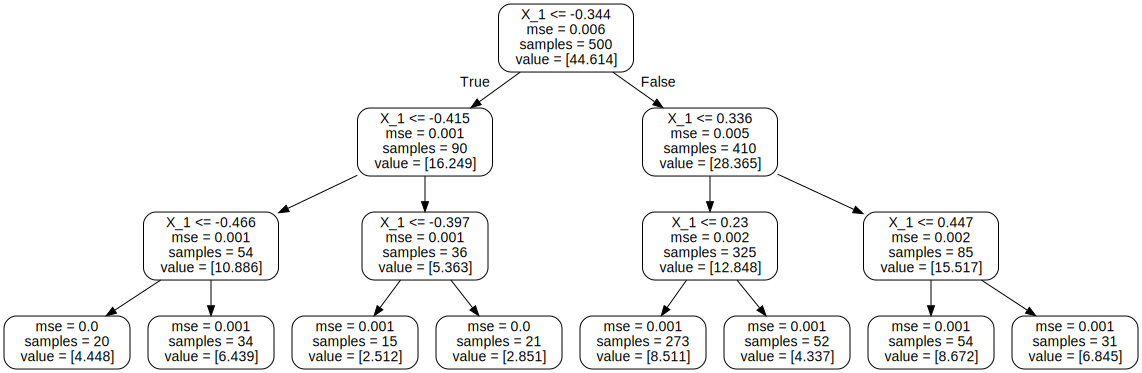

In [213]:
Source.from_file("custom_tree_reg_depth3.dot")

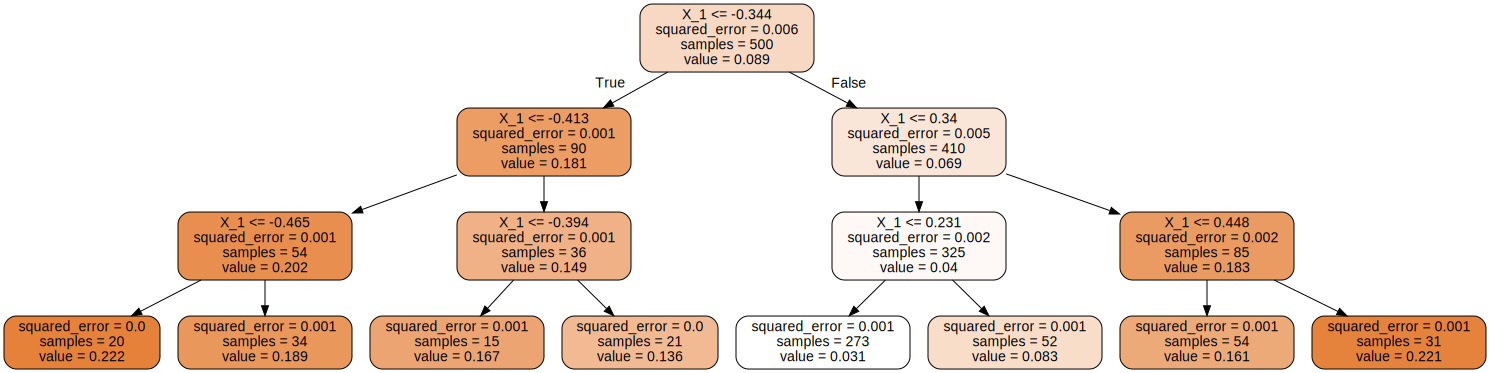

In [207]:
Source.from_file("org_tree_reg_depth3.dot")